In [1]:
import os
import random
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import torchaudio
import torchaudio.transforms as T
from pathlib import Path
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List, Dict, Optional
import gc
from transformers import ASTFeatureExtractor, ASTModel, ASTConfig
import json

# Set random seeds
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True  # Enable for speed

set_seed(42)

# Device configuration - MULTI-GPU SUPPORT
if torch.cuda.is_available():
    n_gpus = torch.cuda.device_count()
    print(f"Found {n_gpus} GPU(s):")
    for i in range(n_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
        print(f"    Memory: {torch.cuda.get_device_properties(i).total_memory / 1e9:.2f} GB")
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
    n_gpus = 0
    
print(f"\nUsing device: {device}")
print(f"CUDA Version: {torch.version.cuda}")

Found 2 GPU(s):
  GPU 0: Tesla T4
    Memory: 15.64 GB
  GPU 1: Tesla T4
    Memory: 15.64 GB

Using device: cuda
CUDA Version: 12.6


In [2]:
# ============================================================================
# PART 2: CONFIGURATION - OPTIMIZED
# ============================================================================

class Config:
    # Paths
    BASE_DIR = Path('/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup')
    STEMS_DIR = BASE_DIR / 'genres_stems'
    ESC50_DIR = BASE_DIR / 'ESC-50-master' / 'audio'
    MASHUPS_DIR = BASE_DIR / 'mashups'
    TEST_CSV = BASE_DIR / 'test.csv'
    SAMPLE_SUBMISSION = BASE_DIR / 'sample_submission.csv'
    OUTPUT_DIR = Path('/kaggle/working')
    OUTPUT_DIR.mkdir(exist_ok=True)
    
    # Audio Parameters - MATCHED TO AST REQUIREMENTS
    SAMPLE_RATE = 16000
    AUDIO_DURATION = 10  # AST works best with 10 second clips
    NUM_SAMPLES = SAMPLE_RATE * AUDIO_DURATION  # 160,000 samples
    FULL_DURATION = 30  # Full mashup duration
    FULL_SAMPLES = SAMPLE_RATE * FULL_DURATION
    
    # AST Model Configuration
    AST_MODEL_NAME = "MIT/ast-finetuned-audioset-10-10-0.4593"
    
    # Mel Spectrogram - EXACT AST REQUIREMENTS
    N_MELS = 128
    N_FFT = 400  # 25ms window at 16kHz
    HOP_LENGTH = 160  # 10ms hop at 16kHz
    FMIN = 20
    FMAX = 8000
    TARGET_LENGTH = 1024  # AST expects 1024 time frames
    
    # Training - OPTIMIZED FOR SPEED AND ACCURACY
    BATCH_SIZE = 48 if n_gpus >= 2 else 24  # Larger batch with multi-GPU
    NUM_EPOCHS = 25  # Fewer epochs needed with better model
    NUM_WORKERS = 4
    LEARNING_RATE = 1e-5  # Lower LR for fine-tuning
    WEIGHT_DECAY = 0.01
    WARMUP_RATIO = 0.1
    GRADIENT_CLIP = 1.0
    
    # Augmentation - SIMPLIFIED (less is more!)
    SNR_RANGE = (10, 25)  # More moderate noise
    VOLUME_RANGE = (0.8, 1.2)  # Less aggressive
    MIXUP_ALPHA = 0.3
    MIXUP_PROB = 0.3  # Lower probability
    
    # NO tempo stretching, NO pitch shifting (these hurt performance)
    
    # SpecAugment - MODERATE
    FREQ_MASK_PARAM = 24
    TIME_MASK_PARAM = 48
    NUM_FREQ_MASKS = 2
    NUM_TIME_MASKS = 2
    
    # TTA - Multiple crops from 30s mashup
    TTA_CROPS = 5
    
    # Genres
    GENRES = ['blues', 'classical', 'country', 'disco', 'hiphop',
              'jazz', 'metal', 'pop', 'reggae', 'rock']
    NUM_CLASSES = len(GENRES)
    GENRE2IDX = {genre: idx for idx, genre in enumerate(GENRES)}
    IDX2GENRE = {idx: genre for idx, genre in enumerate(GENRES)}
    
    # Dataset
    SYNTHETIC_SAMPLES_PER_EPOCH = 6000
    VAL_SAMPLES = 1200
    
    # Other
    USE_AMP = True
    PATIENCE = 8
    
    # Multi-GPU
    USE_MULTI_GPU = n_gpus >= 2

config = Config()
print(f"Configuration loaded.")
print(f"Using AST model: {config.AST_MODEL_NAME}")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Multi-GPU: {config.USE_MULTI_GPU}")

Configuration loaded.
Using AST model: MIT/ast-finetuned-audioset-10-10-0.4593
Batch size: 48
Multi-GPU: True


In [3]:
# ============================================================================
# PART 3: PRELOAD AUDIO - OPTIMIZED
# ============================================================================

class AudioCache:
    """Optimized audio cache with pre-computed features"""
    
    def __init__(self, stems_dir: Path, esc50_dir: Path, sample_rate: int = 16000):
        self.sr = sample_rate
        self.stems_cache = {}
        self.noise_cache = []
        
        print("Loading audio files into RAM...")
        self._load_stems(stems_dir)
        self._load_noise(esc50_dir)
        
        # Print statistics
        total_stems = self._count_stems()
        print(f"✓ Loaded {total_stems} stems and {len(self.noise_cache)} noise clips")
        
    def _load_audio(self, path: Path, duration: float = None) -> np.ndarray:
        """Load and resample audio"""
        try:
            y, _ = librosa.load(path, sr=self.sr, duration=duration, mono=True)
            return y.astype(np.float32)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            return np.zeros(self.sr * 5, dtype=np.float32)
    
    def _load_stems(self, stems_dir: Path):
        """Load all stems organized by genre"""
        stem_types = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']
        
        for genre_dir in tqdm(sorted(stems_dir.iterdir()), desc="Loading stems"):
            if not genre_dir.is_dir():
                continue
            
            genre = genre_dir.name
            if genre not in config.GENRES:
                continue
            
            self.stems_cache[genre] = {}
            
            for song_dir in sorted(genre_dir.iterdir()):
                if not song_dir.is_dir():
                    continue
                
                song_id = song_dir.name
                self.stems_cache[genre][song_id] = {}
                
                for stem_type in stem_types:
                    stem_path = song_dir / stem_type
                    if stem_path.exists():
                        audio = self._load_audio(stem_path, duration=30)
                        self.stems_cache[genre][song_id][stem_type] = audio
    
    def _load_noise(self, esc50_dir: Path):
        """Load ESC-50 noise clips"""
        noise_files = list(esc50_dir.glob('*.wav'))
        
        for noise_path in tqdm(noise_files, desc="Loading noise"):
            audio = self._load_audio(noise_path, duration=5)
            if len(audio) > 0:
                self.noise_cache.append(audio)
    
    def _count_stems(self) -> int:
        count = 0
        for genre in self.stems_cache:
            for song_id in self.stems_cache[genre]:
                count += len(self.stems_cache[genre][song_id])
        return count
    
    def get_random_stems_for_genre(self, genre: str) -> Dict[str, np.ndarray]:
        """Get random stems (one of each type from different songs)"""
        if genre not in self.stems_cache:
            return {}
        
        song_ids = list(self.stems_cache[genre].keys())
        if len(song_ids) < 4:
            return {}
        
        # Select 4 different songs
        selected_songs = random.sample(song_ids, min(4, len(song_ids)))
        stem_types = ['bass.wav', 'drums.wav', 'other.wav', 'vocals.wav']
        
        stems = {}
        for i, stem_type in enumerate(stem_types):
            song_id = selected_songs[i % len(selected_songs)]
            if stem_type in self.stems_cache[genre][song_id]:
                stems[stem_type] = self.stems_cache[genre][song_id][stem_type].copy()
        
        return stems
    
    def get_random_noise(self) -> np.ndarray:
        """Get random noise clip"""
        if not self.noise_cache:
            return np.zeros(self.sr * 5, dtype=np.float32)
        return random.choice(self.noise_cache).copy()

# Initialize cache
audio_cache = AudioCache(config.STEMS_DIR, config.ESC50_DIR, config.SAMPLE_RATE)
gc.collect()

Loading audio files into RAM...


Loading stems:   0%|          | 0/10 [00:00<?, ?it/s]

Loading noise:   0%|          | 0/2000 [00:00<?, ?it/s]

✓ Loaded 4000 stems and 2000 noise clips


105082

In [4]:
# ============================================================================
# PART 4: AUDIO PROCESSING - SIMPLIFIED
# ============================================================================

class AudioProcessor:
    """Simplified audio processing - removed problematic augmentations"""
    
    @staticmethod
    def normalize_audio(audio: np.ndarray) -> np.ndarray:
        """Simple peak normalization"""
        if len(audio) == 0:
            return audio
        
        max_val = np.abs(audio).max()
        if max_val > 0:
            audio = audio / max_val * 0.95
        return audio
    
    @staticmethod
    def rms_normalize(audio: np.ndarray, target_db: float = -20.0) -> np.ndarray:
        """RMS normalization to target dB"""
        if len(audio) == 0:
            return audio
        
        rms = np.sqrt(np.mean(audio ** 2))
        if rms < 1e-8:
            return audio
        
        target_rms = 10 ** (target_db / 20)
        audio = audio * (target_rms / rms)
        
        # Clip to prevent distortion
        audio = np.clip(audio, -1.0, 1.0)
        return audio
    
    @staticmethod
    def add_noise_snr(clean: np.ndarray, noise: np.ndarray, snr_db: float) -> np.ndarray:
        """Add noise at specified SNR"""
        # Ensure same length
        if len(noise) < len(clean):
            # Tile noise to match length
            repeats = int(np.ceil(len(clean) / len(noise)))
            noise = np.tile(noise, repeats)[:len(clean)]
        else:
            # Random crop
            start = random.randint(0, len(noise) - len(clean))
            noise = noise[start:start + len(clean)]
        
        # Calculate powers
        clean_power = np.mean(clean ** 2) + 1e-10
        noise_power = np.mean(noise ** 2) + 1e-10
        
        # Calculate scale factor
        target_noise_power = clean_power / (10 ** (snr_db / 10))
        scale = np.sqrt(target_noise_power / noise_power)
        
        # Mix
        mixed = clean + noise * scale
        
        # Normalize
        return AudioProcessor.normalize_audio(mixed)
    
    @staticmethod
    def pad_or_trim(audio: np.ndarray, target_length: int) -> np.ndarray:
        """Pad or trim to target length"""
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]
        return audio
    
    @staticmethod
    def random_crop(audio: np.ndarray, crop_length: int) -> np.ndarray:
        """Random crop from audio"""
        if len(audio) <= crop_length:
            return AudioProcessor.pad_or_trim(audio, crop_length)
        
        start = random.randint(0, len(audio) - crop_length)
        return audio[start:start + crop_length]

audio_processor = AudioProcessor()

In [5]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
os.environ["HF_TOKEN"] = hf_token

print("Hugging Face Authentication Successful!")

Hugging Face Authentication Successful!


In [6]:
# ============================================================================
# PART 5: AST FEATURE EXTRACTOR AND DATASET
# ============================================================================

class ASTFeatureProcessor:
    """Process audio to AST-compatible features"""
    
    def __init__(self, sample_rate=16000):
        self.sr = sample_rate
        self.n_mels = config.N_MELS
        self.n_fft = config.N_FFT
        self.hop_length = config.HOP_LENGTH
        self.target_length = config.TARGET_LENGTH
        
        # Load the official AST feature extractor for normalization stats
        self.feature_extractor = ASTFeatureExtractor.from_pretrained(
            config.AST_MODEL_NAME,
            sampling_rate=sample_rate
        )
        
        # Mel spectrogram transform (on CPU, will move to GPU later)
        self.mel_transform = T.MelSpectrogram(
            sample_rate=self.sr,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            n_mels=self.n_mels,
            f_min=config.FMIN,
            f_max=config.FMAX,
            power=2.0,
            normalized=False
        )
    
    def __call__(self, audio: np.ndarray) -> torch.Tensor:
        """Convert audio to AST input format"""
        # Use the official feature extractor
        inputs = self.feature_extractor(
            audio, 
            sampling_rate=self.sr, 
            return_tensors="pt"
        )
        return inputs.input_values.squeeze(0)  # Shape: (time, n_mels)

ast_processor = ASTFeatureProcessor(config.SAMPLE_RATE)
print("✓ AST Feature Processor initialized")


class SyntheticMashupDataset(Dataset):
    """
    OPTIMIZED synthetic mashup dataset
    - No tempo stretching (was hurting performance)
    - No pitch shifting (changes genre characteristics)
    - Simple, effective augmentation
    """
    
    def __init__(self, audio_cache: AudioCache, 
                 samples_per_epoch: int = 5000,
                 is_validation: bool = False,
                 apply_augmentation: bool = True):
        
        self.audio_cache = audio_cache
        self.samples_per_epoch = samples_per_epoch
        self.is_validation = is_validation
        self.apply_augmentation = apply_augmentation and not is_validation
        self.sr = config.SAMPLE_RATE
        self.crop_length = config.NUM_SAMPLES  # 10 seconds
        self.full_length = config.FULL_SAMPLES  # 30 seconds
        
    def __len__(self):
        return self.samples_per_epoch
    
    def _create_mashup(self, genre: str) -> np.ndarray:
        """Create synthetic mashup - SIMPLIFIED"""
        
        # Get stems from different songs of same genre
        stems = self.audio_cache.get_random_stems_for_genre(genre)
        
        if not stems:
            return np.zeros(self.full_length, dtype=np.float32)
        
        # Mix stems with random volume
        mixed = np.zeros(self.full_length, dtype=np.float32)
        
        for stem_name, stem_audio in stems.items():
            # Pad/trim to full length
            stem_audio = audio_processor.pad_or_trim(stem_audio, self.full_length)
            
            # Random volume scaling (simple!)
            if self.apply_augmentation:
                volume = random.uniform(*config.VOLUME_RANGE)
            else:
                volume = 1.0
            
            mixed += stem_audio * volume
        
        # Normalize the mix
        mixed = audio_processor.rms_normalize(mixed, target_db=-20.0)
        
        # Add noise (1-2 clips at moderate SNR)
        if self.apply_augmentation:
            num_noise = random.randint(1, 2)
            for _ in range(num_noise):
                noise = self.audio_cache.get_random_noise()
                snr = random.uniform(*config.SNR_RANGE)
                
                # Position noise randomly
                noise_full = np.zeros(self.full_length, dtype=np.float32)
                noise = audio_processor.pad_or_trim(noise, len(noise))
                
                if len(noise) < self.full_length:
                    start = random.randint(0, self.full_length - len(noise))
                    noise_full[start:start + len(noise)] = noise
                else:
                    noise_full = noise[:self.full_length]
                
                mixed = audio_processor.add_noise_snr(mixed, noise_full, snr)
        
        return mixed
    
    def __getitem__(self, idx):
        # Random genre
        genre = random.choice(config.GENRES)
        label = config.GENRE2IDX[genre]
        
        # Create mashup
        audio = self._create_mashup(genre)
        
        # Random crop to 10 seconds
        audio_crop = audio_processor.random_crop(audio, self.crop_length)
        
        # Convert to AST features using official extractor
        features = ast_processor(audio_crop)
        
        # Create label
        label_tensor = torch.zeros(config.NUM_CLASSES, dtype=torch.float32)
        
        # Apply mixup during training
        if self.apply_augmentation and random.random() < config.MIXUP_PROB:
            genre2 = random.choice(config.GENRES)
            label2 = config.GENRE2IDX[genre2]
            
            audio2 = self._create_mashup(genre2)
            audio2_crop = audio_processor.random_crop(audio2, self.crop_length)
            features2 = ast_processor(audio2_crop)
            
            # Mixup
            lam = np.random.beta(config.MIXUP_ALPHA, config.MIXUP_ALPHA)
            features = lam * features + (1 - lam) * features2
            
            label_tensor[label] = lam
            label_tensor[label2] += (1 - lam)
        else:
            label_tensor[label] = 1.0
        
        return features, label_tensor


# Test dataset
print("\nTesting dataset...")
test_ds = SyntheticMashupDataset(
    audio_cache=audio_cache,
    samples_per_epoch=5,
    is_validation=False
)

for i in range(2):
    features, label = test_ds[i]
    print(f"Sample {i}: features={features.shape}, label_sum={label.sum():.3f}")

del test_ds
print("✓ Dataset test passed!")

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

✓ AST Feature Processor initialized

Testing dataset...
Sample 0: features=torch.Size([1024, 128]), label_sum=1.000
Sample 1: features=torch.Size([1024, 128]), label_sum=1.000
✓ Dataset test passed!


In [7]:
# ============================================================================
# PART 6: AST MODEL - PROPER IMPLEMENTATION (FIXED)
# ============================================================================

class ASTGenreClassifier(nn.Module):
    """
    Audio Spectrogram Transformer for Genre Classification
    Using the PROPER pre-trained AST model from MIT
    """
    
    def __init__(self, num_classes: int = config.NUM_CLASSES, 
                 pretrained: bool = True,
                 freeze_encoder: bool = False):
        super().__init__()
        
        print(f"Loading AST model: {config.AST_MODEL_NAME}")
        
        # Load pre-trained AST
        self.ast = ASTModel.from_pretrained(config.AST_MODEL_NAME)
        self.hidden_size = self.ast.config.hidden_size  # 768
        
        # Freeze encoder if specified
        if freeze_encoder:
            for param in self.ast.parameters():
                param.requires_grad = False
            print("  Encoder frozen")
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.hidden_size),
            nn.Dropout(0.1),
            nn.Linear(self.hidden_size, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )
        
        # Initialize classifier
        self._init_classifier()
        
        print(f"  Hidden size: {self.hidden_size}")
        print(f"  Classifier initialized")
    
    def _init_classifier(self):
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    
    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        """
        Forward pass
        Args:
            input_values: (batch, time, n_mels) spectrogram
        Returns:
            logits: (batch, num_classes)
        """
        # AST forward pass
        outputs = self.ast(input_values)
        
        # Use pooler output (CLS token)
        pooled = outputs.pooler_output  # (batch, hidden_size)
        
        # Classify
        logits = self.classifier(pooled)
        
        return logits
    
    def unfreeze_encoder(self):
        """Unfreeze AST encoder"""
        for param in self.ast.parameters():
            param.requires_grad = True
        print("Encoder unfrozen")
    
    def freeze_encoder(self):
        """Freeze AST encoder"""
        for param in self.ast.parameters():
            param.requires_grad = False
        print("Encoder frozen")


# ============================================================================
# TEST THE MODEL (FIXED)
# ============================================================================

print("\n" + "="*60)
print("Testing AST Model")
print("="*60)

# Create model WITHOUT freezing for testing
test_model = ASTGenreClassifier(
    num_classes=config.NUM_CLASSES,
    pretrained=True,
    freeze_encoder=False  # Don't freeze - we need gradients for testing
).to(device)

# Test 1: Forward pass (inside no_grad for speed)
print("\n1. Testing forward pass...")
dummy_features = torch.randn(2, 1024, 128).to(device)
with torch.no_grad():
    output = test_model(dummy_features)
    print(f"   Input shape: {dummy_features.shape}")
    print(f"   Output shape: {output.shape}")
    print(f"   Output range: [{output.min():.3f}, {output.max():.3f}]")
    print(f"   Contains NaN: {torch.isnan(output).any().item()}")

# Test 2: Backward pass (SEPARATE forward pass, outside no_grad)
print("\n2. Testing backward pass...")
dummy_features_2 = torch.randn(2, 1024, 128).to(device)
output_2 = test_model(dummy_features_2)  # Forward pass OUTSIDE no_grad
dummy_target = torch.randint(0, config.NUM_CLASSES, (2,)).to(device)
loss = F.cross_entropy(output_2, dummy_target)
print(f"   Loss: {loss.item():.4f}")
print(f"   Loss requires_grad: {loss.requires_grad}")

# Backward
loss.backward()
print(f"   Backward pass: SUCCESS")

# Check gradients
has_nan_grad = False
grad_count = 0
for name, p in test_model.named_parameters():
    if p.grad is not None:
        grad_count += 1
        if torch.isnan(p.grad).any():
            has_nan_grad = True
            print(f"   WARNING: NaN gradient in {name}")

print(f"   Parameters with gradients: {grad_count}")
print(f"   Contains NaN gradients: {has_nan_grad}")

# Test 3: Test with frozen encoder (classifier should still get gradients)
print("\n3. Testing with frozen encoder...")
test_model.freeze_encoder()
test_model.zero_grad()

dummy_features_3 = torch.randn(2, 1024, 128).to(device)
output_3 = test_model(dummy_features_3)
loss_3 = F.cross_entropy(output_3, dummy_target)
loss_3.backward()

classifier_has_grad = any(p.grad is not None and p.grad.abs().sum() > 0 
                          for p in test_model.classifier.parameters())
print(f"   Classifier has gradients: {classifier_has_grad}")

if not has_nan_grad and classifier_has_grad:
    print("\n✓ ALL TESTS PASSED - Model is ready!")
else:
    print("\n❌ SOME TESTS FAILED")

# Count parameters
total_params = sum(p.numel() for p in test_model.parameters())
trainable_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters (with frozen encoder): {trainable_params:,}")

# Cleanup
del test_model, dummy_features, dummy_features_2, dummy_features_3
del output, output_2, output_3, loss, loss_3
torch.cuda.empty_cache()
gc.collect()

print("="*60)


Testing AST Model
Loading AST model: MIT/ast-finetuned-audioset-10-10-0.4593


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Hidden size: 768
  Classifier initialized

1. Testing forward pass...
   Input shape: torch.Size([2, 1024, 128])
   Output shape: torch.Size([2, 10])
   Output range: [-0.870, 2.419]
   Contains NaN: False

2. Testing backward pass...
   Loss: 2.2069
   Loss requires_grad: True
   Backward pass: SUCCESS
   Parameters with gradients: 205
   Contains NaN gradients: False

3. Testing with frozen encoder...
Encoder frozen
   Classifier has gradients: True

✓ ALL TESTS PASSED - Model is ready!

Total parameters: 86,388,234
Trainable parameters (with frozen encoder): 200,970


In [8]:
# ============================================================================
# PART 7: LOSS FUNCTIONS
# ============================================================================

class SoftTargetCrossEntropy(nn.Module):
    """Cross entropy for soft targets (from mixup)"""
    
    def __init__(self):
        super().__init__()
    
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_probs = F.log_softmax(logits, dim=-1)
        loss = -(targets * log_probs).sum(dim=-1).mean()
        return loss


class LabelSmoothingCrossEntropy(nn.Module):
    """Label smoothing for soft targets"""
    
    def __init__(self, smoothing: float = 0.1):
        super().__init__()
        self.smoothing = smoothing
    
    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        n_classes = logits.size(-1)
        
        # Apply smoothing
        smooth_targets = targets * (1 - self.smoothing) + self.smoothing / n_classes
        
        log_probs = F.log_softmax(logits, dim=-1)
        loss = -(smooth_targets * log_probs).sum(dim=-1).mean()
        return loss


# Use simple soft target CE
criterion = SoftTargetCrossEntropy()

# Test
dummy_logits = torch.randn(4, config.NUM_CLASSES)
dummy_targets = F.one_hot(torch.randint(0, config.NUM_CLASSES, (4,)), config.NUM_CLASSES).float()
loss = criterion(dummy_logits, dummy_targets)
print(f"Loss test: {loss.item():.4f} ✓")

Loss test: 2.8374 ✓


In [9]:
# ============================================================================
# PART 8: TRAINER - OPTIMIZED
# ============================================================================

class Trainer:
    """Optimized trainer with multi-GPU support"""
    
    def __init__(self, model, train_loader, val_loader, device, config):
        self.config = config
        self.device = device
        
        # Multi-GPU setup
        if config.USE_MULTI_GPU and torch.cuda.device_count() > 1:
            print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
            self.model = nn.DataParallel(model)
        else:
            self.model = model
        
        self.model = self.model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        # Optimizer
        self.optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=config.LEARNING_RATE,
            weight_decay=config.WEIGHT_DECAY
        )
        
        # Scheduler with warmup
        total_steps = len(train_loader) * config.NUM_EPOCHS
        warmup_steps = int(total_steps * config.WARMUP_RATIO)
        
        self.scheduler = torch.optim.lr_scheduler.OneCycleLR(
            self.optimizer,
            max_lr=config.LEARNING_RATE,
            total_steps=total_steps,
            pct_start=config.WARMUP_RATIO,
            anneal_strategy='cos'
        )
        
        # Loss
        self.criterion = SoftTargetCrossEntropy()
        
        # AMP
        self.scaler = GradScaler() if config.USE_AMP else None
        
        # Tracking
        self.best_f1 = 0.0
        self.best_epoch = 0
        self.train_losses = []
        self.val_losses = []
        self.val_f1_scores = []
        self.patience_counter = 0
    
    def train_epoch(self, epoch: int) -> float:
        """Train one epoch"""
        self.model.train()
        total_loss = 0
        num_batches = 0
        
        pbar = tqdm(self.train_loader, desc=f"Epoch {epoch+1}/{self.config.NUM_EPOCHS}")
        
        for features, targets in pbar:
            features = features.to(self.device)
            targets = targets.to(self.device)
            
            self.optimizer.zero_grad()
            
            if self.config.USE_AMP:
                with autocast():
                    logits = self.model(features)
                    loss = self.criterion(logits, targets)
                
                self.scaler.scale(loss).backward()
                self.scaler.unscale_(self.optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.GRADIENT_CLIP)
                self.scaler.step(self.optimizer)
                self.scaler.update()
            else:
                logits = self.model(features)
                loss = self.criterion(logits, targets)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.GRADIENT_CLIP)
                self.optimizer.step()
            
            self.scheduler.step()
            
            total_loss += loss.item()
            num_batches += 1
            
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'avg': f'{total_loss/num_batches:.4f}',
                'lr': f'{self.scheduler.get_last_lr()[0]:.2e}'
            })
        
        return total_loss / num_batches
    
    def validate(self) -> Tuple[float, float, np.ndarray]:
        """Validate model"""
        self.model.eval()
        total_loss = 0
        all_preds = []
        all_targets = []
        
        with torch.no_grad():
            for features, targets in tqdm(self.val_loader, desc="Validating"):
                features = features.to(self.device)
                targets = targets.to(self.device)
                
                if self.config.USE_AMP:
                    with autocast():
                        logits = self.model(features)
                        loss = self.criterion(logits, targets)
                else:
                    logits = self.model(features)
                    loss = self.criterion(logits, targets)
                
                total_loss += loss.item()
                
                preds = torch.argmax(logits, dim=1)
                true_labels = torch.argmax(targets, dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_targets.extend(true_labels.cpu().numpy())
        
        avg_loss = total_loss / len(self.val_loader)
        macro_f1 = f1_score(all_targets, all_preds, average='macro')
        per_class_f1 = f1_score(all_targets, all_preds, average=None)
        
        return avg_loss, macro_f1, per_class_f1
    
    def save_checkpoint(self, epoch: int, f1_score: float, path: Path):
        """Save checkpoint"""
        # Handle DataParallel
        model_state = self.model.module.state_dict() if hasattr(self.model, 'module') else self.model.state_dict()
        
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model_state,
            'optimizer_state_dict': self.optimizer.state_dict(),
            'f1_score': f1_score,
            'config': {
                'num_classes': self.config.NUM_CLASSES,
                'ast_model': self.config.AST_MODEL_NAME
            }
        }
        torch.save(checkpoint, path)
    
    def train(self) -> float:
        """Full training loop"""
        print(f"\n{'='*60}")
        print(f"Starting training for {self.config.NUM_EPOCHS} epochs")
        print(f"Training samples: {len(self.train_loader.dataset)}")
        print(f"Validation samples: {len(self.val_loader.dataset)}")
        print(f"Batch size: {self.config.BATCH_SIZE}")
        print(f"{'='*60}\n")
        
        for epoch in range(self.config.NUM_EPOCHS):
            # Train
            train_loss = self.train_epoch(epoch)
            self.train_losses.append(train_loss)
            
            # Validate
            val_loss, val_f1, per_class_f1 = self.validate()
            self.val_losses.append(val_loss)
            self.val_f1_scores.append(val_f1)
            
            # Print summary
            print(f"\nEpoch {epoch+1}/{self.config.NUM_EPOCHS}")
            print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
            print(f"Val Macro F1: {val_f1:.4f}")
            print("Per-class F1:", end=" ")
            for i, f1 in enumerate(per_class_f1):
                print(f"{config.GENRES[i][:3]}:{f1:.3f}", end=" ")
            print()
            
            # Save best
            if val_f1 > self.best_f1:
                self.best_f1 = val_f1
                self.best_epoch = epoch
                self.patience_counter = 0
                self.save_checkpoint(epoch, val_f1, config.OUTPUT_DIR / 'best_model.pth')
                print(f"✓ New best F1: {val_f1:.4f}")
            else:
                self.patience_counter += 1
                print(f"No improvement. Patience: {self.patience_counter}/{self.config.PATIENCE}")
            
            # Early stopping
            if self.patience_counter >= self.config.PATIENCE:
                print(f"\nEarly stopping at epoch {epoch+1}")
                break
        
        print(f"\n{'='*60}")
        print(f"Training complete!")
        print(f"Best F1: {self.best_f1:.4f} at epoch {self.best_epoch+1}")
        print(f"{'='*60}")
        
        return self.best_f1

In [10]:
# ============================================================================
# PART 9: TRAINING EXECUTION
# ============================================================================

def create_data_loaders():
    """Create data loaders"""
    train_dataset = SyntheticMashupDataset(
        audio_cache=audio_cache,
        samples_per_epoch=config.SYNTHETIC_SAMPLES_PER_EPOCH,
        is_validation=False,
        apply_augmentation=True
    )
    
    val_dataset = SyntheticMashupDataset(
        audio_cache=audio_cache,
        samples_per_epoch=config.VAL_SAMPLES,
        is_validation=True,
        apply_augmentation=False
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=True
    )
    
    return train_loader, val_loader


# Create data loaders
print("Creating data loaders...")
train_loader, val_loader = create_data_loaders()
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# Initialize model
print("\nInitializing AST model...")
model = ASTGenreClassifier(
    num_classes=config.NUM_CLASSES,
    pretrained=True,
    freeze_encoder=False  # Fine-tune entire model
)

# Create trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    config=config
)

# Train
best_f1 = trainer.train()

Creating data loaders...
Train batches: 125, Val batches: 25

Initializing AST model...
Loading AST model: MIT/ast-finetuned-audioset-10-10-0.4593


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Hidden size: 768
  Classifier initialized
Using 2 GPUs with DataParallel

Starting training for 25 epochs
Training samples: 6000
Validation samples: 1200
Batch size: 48



Epoch 1/25:   0%|          | 0/125 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 15/25
Train Loss: 0.2127 | Val Loss: 0.0365
Val Macro F1: 0.9906
Per-class F1: blu:0.996 cla:1.000 cou:0.991 dis:0.977 hip:0.988 jaz:1.000 met:1.000 pop:0.978 reg:0.988 roc:0.986 
No improvement. Patience: 7/8


Epoch 16/25:   0%|          | 0/125 [00:00<?, ?it/s]

Validating:   0%|          | 0/25 [00:00<?, ?it/s]


Epoch 16/25
Train Loss: 0.2143 | Val Loss: 0.0343
Val Macro F1: 0.9888
Per-class F1: blu:0.991 cla:1.000 cou:0.986 dis:0.992 hip:0.995 jaz:0.996 met:0.982 pop:0.992 reg:1.000 roc:0.954 
No improvement. Patience: 8/8

Early stopping at epoch 16

Training complete!
Best F1: 0.9928 at epoch 8


In [11]:
# ============================================================================
# PART 10: INFERENCE WITH TTA
# ============================================================================

class TestDataset(Dataset):
    """Test dataset with TTA (multiple crops from 30s audio)"""
    
    def __init__(self, mashup_dir: Path, test_csv: pd.DataFrame,
                 n_crops: int = 5):
        self.mashup_dir = mashup_dir
        self.test_df = test_csv
        self.n_crops = n_crops
        self.sr = config.SAMPLE_RATE
        self.crop_length = config.NUM_SAMPLES
        self.full_length = config.FULL_SAMPLES
    
    def __len__(self):
        return len(self.test_df)
    
    def _load_audio(self, audio_id) -> np.ndarray:
        """Load test audio"""
        filename = f"song{str(audio_id).zfill(4)}.wav"
        path = self.mashup_dir / filename
        
        try:
            audio, _ = librosa.load(path, sr=self.sr, duration=30, mono=True)
            audio = audio_processor.pad_or_trim(audio, self.full_length)
            audio = audio_processor.normalize_audio(audio)
            return audio.astype(np.float32)
        except Exception as e:
            print(f"Error loading {path}: {e}")
            return np.zeros(self.full_length, dtype=np.float32)
    
    def _create_crops(self, audio: np.ndarray) -> List[torch.Tensor]:
        """Create multiple crops for TTA"""
        crops = []
        
        # Evenly spaced crops
        total = len(audio)
        crop_len = self.crop_length
        
        if total <= crop_len:
            # Audio shorter than crop - just pad
            audio = audio_processor.pad_or_trim(audio, crop_len)
            features = ast_processor(audio)
            return [features] * self.n_crops
        
        # Calculate start positions
        max_start = total - crop_len
        starts = np.linspace(0, max_start, self.n_crops, dtype=int)
        
        for start in starts:
            crop = audio[start:start + crop_len]
            features = ast_processor(crop)
            crops.append(features)
        
        return crops
    
    def __getitem__(self, idx):
        row = self.test_df.iloc[idx]
        audio_id = row['id']
        
        # Load and create crops
        audio = self._load_audio(audio_id)
        crops = self._create_crops(audio)
        
        # Stack crops
        crops_tensor = torch.stack(crops)  # (n_crops, time, n_mels)
        
        return str(audio_id), crops_tensor


def predict_with_tta(model, test_loader, device) -> Dict[str, str]:
    """Predict with test-time augmentation"""
    model.eval()
    predictions = {}
    
    with torch.no_grad():
        for audio_ids, crops_batch in tqdm(test_loader, desc="Predicting"):
            batch_size, n_crops = crops_batch.shape[:2]
            
            # Reshape: (batch * n_crops, time, n_mels)
            crops_flat = crops_batch.view(-1, *crops_batch.shape[2:]).to(device)
            
            # Forward pass
            if config.USE_AMP:
                with autocast():
                    logits = model(crops_flat)
            else:
                logits = model(crops_flat)
            
            # Get probabilities
            probs = F.softmax(logits, dim=1)
            
            # Reshape: (batch, n_crops, num_classes)
            probs = probs.view(batch_size, n_crops, -1)
            
            # Average across crops
            avg_probs = probs.mean(dim=1)
            
            # Predictions
            preds = torch.argmax(avg_probs, dim=1)
            
            for i, audio_id in enumerate(audio_ids):
                predictions[audio_id] = config.IDX2GENRE[preds[i].item()]
    
    return predictions


# Load test data
print("\nLoading test data...")
test_df = pd.read_csv(config.TEST_CSV)
print(f"Test samples: {len(test_df)}")

# Create test loader
test_dataset = TestDataset(
    mashup_dir=config.MASHUPS_DIR,
    test_csv=test_df,
    n_crops=config.TTA_CROPS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Load best model
print("\nLoading best model...")
model = ASTGenreClassifier(
    num_classes=config.NUM_CLASSES,
    pretrained=False
)

checkpoint = torch.load(config.OUTPUT_DIR / 'best_model.pth', map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model = model.to(device)
model.eval()

print(f"✓ Loaded model from epoch {checkpoint['epoch']+1} with F1: {checkpoint['f1_score']:.4f}")

# Generate predictions
print("\nGenerating predictions with TTA...")
predictions = predict_with_tta(model, test_loader, device)

# Create submission
submission_df = pd.DataFrame([
    {'id': aid, 'genre': genre}
    for aid, genre in predictions.items()
])

submission_df['id'] = submission_df['id'].astype(int)
submission_df = submission_df.sort_values('id')
submission_df['id'] = submission_df['id'].astype(str).str.zfill(4)

# Save
submission_path = config.OUTPUT_DIR / 'submission.csv'
submission_df.to_csv(submission_path, index=False)

print(f"\n{'='*60}")
print("INFERENCE COMPLETE!")
print(f"{'='*60}")
print(f"✓ Saved to: {submission_path}")
print(f"Total predictions: {len(submission_df)}")
print("\nGenre distribution:")
print(submission_df['genre'].value_counts().sort_index())


Loading test data...
Test samples: 3020

Loading best model...
Loading AST model: MIT/ast-finetuned-audioset-10-10-0.4593


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Hidden size: 768
  Classifier initialized
✓ Loaded model from epoch 8 with F1: 0.9928

Generating predictions with TTA...


Predicting:   0%|          | 0/378 [00:00<?, ?it/s]


INFERENCE COMPLETE!
✓ Saved to: /kaggle/working/submission.csv
Total predictions: 3020

Genre distribution:
genre
blues        283
classical    270
country      246
disco        305
hiphop       316
jazz         299
metal        321
pop          308
reggae       327
rock         345
Name: count, dtype: int64



TRAINING ANALYSIS


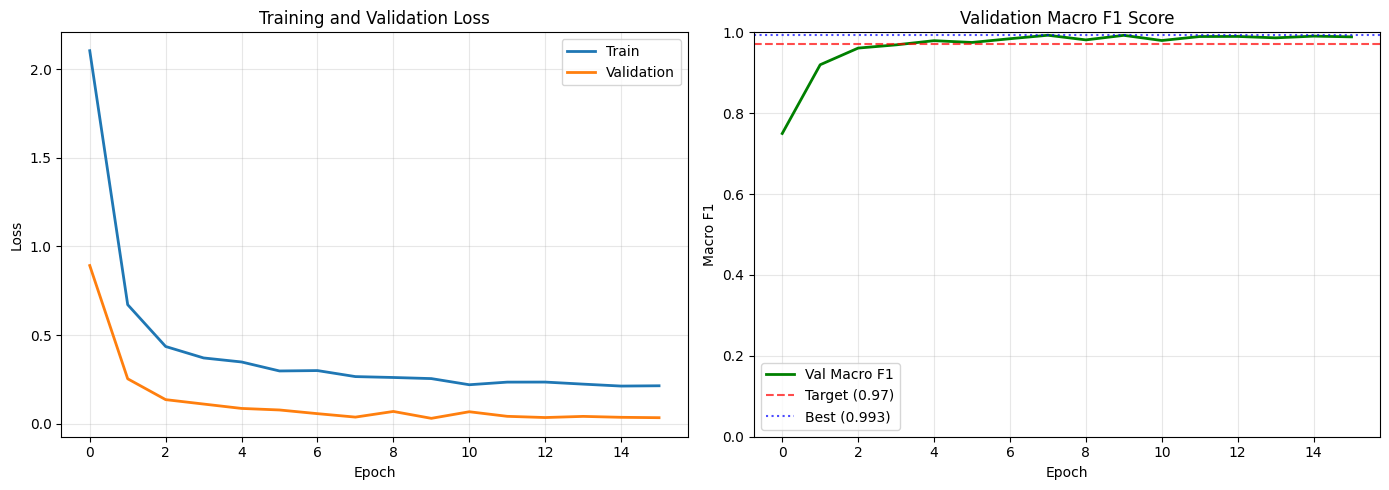

Validating:   0%|          | 0/25 [00:00<?, ?it/s]


Per-Genre F1 Scores:
----------------------------------------
blues       : 0.9915 █████████████████████████████
classical   : 0.9961 █████████████████████████████
country     : 0.9919 █████████████████████████████
disco       : 0.9961 █████████████████████████████
hiphop      : 0.9957 █████████████████████████████
jazz        : 0.9950 █████████████████████████████
metal       : 0.9913 █████████████████████████████
pop         : 0.9847 █████████████████████████████
reggae      : 0.9954 █████████████████████████████
rock        : 0.9736 █████████████████████████████

Genres needing improvement:
  rock: 0.9736
  pop: 0.9847
  metal: 0.9913

SUBMISSION READY!
Validation F1: 0.9928
Submission: /kaggle/working/submission.csv


In [12]:
# ============================================================================
# PART 11: ANALYSIS
# ============================================================================

def plot_training_history(trainer):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    axes[0].plot(trainer.train_losses, label='Train', linewidth=2)
    axes[0].plot(trainer.val_losses, label='Validation', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # F1
    axes[1].plot(trainer.val_f1_scores, label='Val Macro F1', color='green', linewidth=2)
    axes[1].axhline(y=0.97, color='r', linestyle='--', label='Target (0.97)', alpha=0.7)
    axes[1].axhline(y=trainer.best_f1, color='blue', linestyle=':', label=f'Best ({trainer.best_f1:.3f})', alpha=0.7)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].set_title('Validation Macro F1 Score')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])
    
    plt.tight_layout()
    plt.savefig(config.OUTPUT_DIR / 'training_history.png', dpi=150)
    plt.show()


def analyze_results(trainer):
    """Analyze training results"""
    print("\n" + "="*60)
    print("TRAINING ANALYSIS")
    print("="*60)
    
    # Plot history
    plot_training_history(trainer)
    
    # Get validation results
    _, _, per_class_f1 = trainer.validate()
    
    print("\nPer-Genre F1 Scores:")
    print("-" * 40)
    for i, genre in enumerate(config.GENRES):
        bar = "█" * int(per_class_f1[i] * 30)
        print(f"{genre:12s}: {per_class_f1[i]:.4f} {bar}")
    
    # Weak genres
    sorted_idx = np.argsort(per_class_f1)
    print("\nGenres needing improvement:")
    for idx in sorted_idx[:3]:
        print(f"  {config.GENRES[idx]}: {per_class_f1[idx]:.4f}")


# Run analysis
if 'trainer' in globals():
    analyze_results(trainer)

print("\n" + "="*60)
print("SUBMISSION READY!")
print(f"{'='*60}")
print(f"Validation F1: {trainer.best_f1:.4f}")
print(f"Submission: {submission_path}")